In [84]:
import sys
print(sys.executable)

/Users/mdtahsinsharif/anaconda3/envs/stream-metrics/bin/python


In [85]:
import os
import tarfile
import shutil
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [86]:
# ===================== CONFIG =====================
query = "q1"
failure = "fails"
cores_list = ["p10"]
#base_dir = Path(failure + "_spark")
base_dir = Path.cwd() #/ "fails_spark"
output_dir = Path("figures_m10k_q1")

# ==================================================

In [87]:
base_dir

PosixPath('/Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/spark')

In [88]:
output_dir.mkdir(parents=True, exist_ok=True)

print("[START] Analysis pipeline starting...")
print(f"Query: {query}")
print(f"Base dir: {base_dir}")
print(f"Output dir: {output_dir}")

pattern = f"fails_spark"
run_dirs = sorted([p for p in base_dir.glob(pattern) if p.is_dir()])

print(f"[INFO] Found {len(run_dirs)} run directories")

if not run_dirs:
    print(f"No runs found for {query}")
    exit(1)

node_data = {}
throughput_summary = {}  # {node: {cores: throughput}}
cluster_throughput = {}

[START] Analysis pipeline starting...
Query: q1
Base dir: /Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/spark
Output dir: figures_m10k_q1
[INFO] Found 1 run directories


In [123]:
def compute_throughput(df):
    return df["auction"].resample(f"{window_seconds}s").size()

In [124]:
# ===================== HELPERS =====================
window_seconds = 0.1
def compute_latency_summary(df):
    return {
        "avg": df["latency_ms"].mean(),
        "p50": df["latency_ms"].quantile(0.50),
        "p95": df["latency_ms"].quantile(0.95),
        "p99": df["latency_ms"].quantile(0.99),
    }

def compute_latency(df):
    r = df["latency_ms"].resample(f"{window_seconds}s")
    return pd.DataFrame({
        "p50": r.quantile(0.5),
        "p95": r.quantile(0.95),
        "p99": r.quantile(0.99),
    })

def smooth(series, w=5):
    return series.rolling(w, min_periods=1).mean()

def detect_failures(tp):
    gaps = []
    start = None

    for ts, v in tp.items():
        if v == 0 and start is None:
            start = ts
        elif v > 0 and start is not None:
            gaps.append((start, ts))
            start = None

    return gaps

def compute_throughput(df):
    return df["auction"].resample(f"{window_seconds}s").size()

In [90]:
def parse_part_file(pf):
    rows = []
    bad = 0

    print(f"[FILE] Processing: {os.path.basename(pf)}")

    with open(pf, "r", errors="ignore") as f:
        for line_num, line in enumerate(f, 1):
            parts = line.rstrip("\n").split(",")

            if len(parts) < 6:
                bad += 1
                continue

            #auction, price, event_time, processed_time= parts

            try:
                auction = parts[0]
                bidder = parts[1]
                price = parts[2]
                event_time = parts[3].strip('"')
                extra = parts[4]
                processed_time = parts[5].strip('"')
                

                rows.append({
                    "auction": int(auction),
                    "bidder": int(auction),
                    "price": float(price),
                    "dateTime": event_time,
                    "extra": extra,
                    "processed_time": processed_time
                })
            except:
                bad += 1

    print(f"    -> parsed rows: {len(rows)} | bad rows: {bad}")
    return pd.DataFrame(rows)

In [91]:
raw_data = {}  # (node, cores) → df

# ===================== LOAD PHASE ONLY =====================
for run_dir in run_dirs:
    tar_name = run_dir.name
    node = tar_name.split("_")[-1]

    print("\n========================================")
    print(f"[RUN] {tar_name}")
    print(f"[NODE] {node}")

    for cores in cores_list:
        data_path = run_dir / "nfs" / "spark" / "nexmark" / "failure" / query / cores

        print(f"[DATA] {cores} → {data_path}")

        if not data_path.exists():
            print(f"[WARN] Missing path")
            continue

        part_files = sorted(glob.glob(str(data_path / "**" / "part-*"), recursive=True))

        if not part_files:
            print(f"[WARN] No part files")
            continue

        dfs = []
        for pf in part_files:
            df_part = parse_part_file(pf)
            if not df_part.empty:
                dfs.append(df_part)

        if not dfs:
            continue

        df = pd.concat(dfs, ignore_index=True)

        # ONLY BASIC PARSING HERE
        df["event_time"] = pd.to_datetime(df["dateTime"], errors="coerce")
        df["processed_time"] = pd.to_datetime(df["processed_time"], errors="coerce")

        df = df.dropna(subset=["event_time", "processed_time"])

        # store raw dataframe ONLY
        raw_data[(node, cores)] = df

        print(f"[LOAD] stored {(node, cores)} → {len(df)} rows")


[RUN] fails_spark
[NODE] spark
[DATA] p10 → /Users/mdtahsinsharif/ece1724_project/Benchmark-Streaming-Databases/spark/fails_spark/nfs/spark/nexmark/failure/q1/p10
[FILE] Processing: part-00000-0f6cf5fc-0912-47ca-a610-cdb84b6dbd89-c012.csv
    -> parsed rows: 100000 | bad rows: 1
[FILE] Processing: part-00000-130cfae8-db57-4b9a-9b13-5698b22591ab-c019.csv
    -> parsed rows: 100000 | bad rows: 1
[FILE] Processing: part-00000-17a7e371-dc0b-4b20-877d-3012bf50b37a-c020.csv
    -> parsed rows: 100000 | bad rows: 1
[FILE] Processing: part-00000-1b3df64b-aee3-479a-9917-d43bb18e8aba-c011.csv
    -> parsed rows: 100000 | bad rows: 1
[FILE] Processing: part-00000-21fc52d0-5b3e-4aa6-ae03-c96a0c5e468e-c024.csv
    -> parsed rows: 100000 | bad rows: 1
[FILE] Processing: part-00000-322749f1-c1bd-4fbc-a15b-a7481656fd96-c014.csv
    -> parsed rows: 100000 | bad rows: 1
[FILE] Processing: part-00000-331309ae-0c7b-4faf-a426-957cc2b8bb27-c003.csv
    -> parsed rows: 100000 | bad rows: 1
[FILE] Processing

In [125]:
node_data = {}
throughput_summary = {}
throughput_timeseries = {}

for (node, cores), df in raw_data.items():

    print("\n========================================")
    print(f"[ANALYSIS] {node} | {cores}")

    # ----------------------------
    # 1. Parse timestamps properly
    # ----------------------------
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
    df["processed_time"] = pd.to_datetime(df["processed_time"], errors="coerce")

    df = df.dropna(subset=["event_time", "processed_time"])

    # ----------------------------
    # 2. Latency (real definition)
    # ----------------------------
    df["latency_ms"] = (
        (df["processed_time"] - df["event_time"])
        .dt.total_seconds() * 1000
    )

    # ----------------------------
    # 3. Throughput (EVENT TIME BASED)
    # ----------------------------
    df = df.sort_values("event_time").set_index("event_time")

    #tp_ss = df.resample("1s").size()   # or "500ms", "2S"
    tp_ss = compute_throughput(df)
    
    throughput_timeseries.setdefault(node, {})[cores] = tp_ss

    avg_tp = tp_ss.mean() if not tp_ss.empty else 0
    throughput_summary.setdefault(node, {})[cores] = avg_tp

    # ----------------------------
    # 4. Store one core for plotting latency
    # ----------------------------
    if cores == "p10":
        node_data[node] = df

    print(f"[TP] {node} {cores}: {avg_tp:.2f}")


[ANALYSIS] spark | p10
[TP] spark p10: 8305.14


In [113]:
'''node_data = {}
throughput_summary = {}
throughput_timeseries = {}

for (node, cores), df in raw_data.items():

    print("\n========================================")
    print(f"[ANALYSIS] {node} | {cores}")

    # ---- synthetic event-time spacing ----
    df = df.sort_values("processed_time").reset_index(drop=True)

    base_time = df["processed_time"].iloc[0]
    #df["processed_time"] = base_time + pd.to_timedelta(df.index, unit="ms")

    # ---- latency ----
    df["latency_ms"] = (
        (df["processed_time"] - df["event_time"])
        .dt.total_seconds() * 1000
    )

    df = df.sort_values("processed_time").set_index("processed_time")

    # store one core for plotting
    if cores == "p10":
        node_data[node] = df

    # ---- throughput ----
    #tp_ss = compute_throughput(df)
    chunk_size = 10000

    df_reset = df.reset_index(drop=True)

    tp_ss = (
        df_reset
        .groupby(df_reset.index // chunk_size)
        .size()
    )
    tp_ss.index = tp_ss.index * chunk_size
    avg_tp = tp_ss.mean() if not tp_ss.empty else 0
    throughput_timeseries.setdefault(node, {})[cores] = tp_ss

    throughput_summary.setdefault(node, {})[cores] = avg_tp

    print(f"[TP] {node} {cores}: {avg_tp:.2f}")'''


[ANALYSIS] spark | p10
[TP] spark p10: 10000.00


In [126]:
throughput_summary

{'spark': {'p10': 8305.136880959704}}

In [127]:
node_data

{'spark':                                   auction   bidder    price  \
 event_time                                                    
 2026-04-23 21:58:14.631000+00:00  7700155  7700155  3513.96   
 2026-04-23 21:58:14.631000+00:00  7700233  7700233  3895.32   
 2026-04-23 21:58:14.631000+00:00  7700103  7700103  3259.72   
 2026-04-23 21:58:14.631000+00:00  7700090  7700090  3196.16   
 2026-04-23 21:58:14.631000+00:00  7700220  7700220  3831.76   
 ...                                   ...      ...      ...   
 2026-04-23 22:03:39.631000+00:00   199752   199752  6265.20   
 2026-04-23 22:03:39.631000+00:00   199622   199622  5629.60   
 2026-04-23 22:03:39.631000+00:00   199492   199492  4994.00   
 2026-04-23 22:03:39.631000+00:00   199531   199531  5184.68   
 2026-04-23 22:03:39.631000+00:00   199882   199882  6900.80   
 
                                                   dateTime  \
 event_time                                                   
 2026-04-23 21:58:14.631000+00:

In [128]:
throughput_timeseries

{'spark': {'p10': event_time
  2026-04-23 21:58:14.600000+00:00    6302
  2026-04-23 21:58:14.700000+00:00    9200
  2026-04-23 21:58:14.800000+00:00    9200
  2026-04-23 21:58:14.900000+00:00    9200
  2026-04-23 21:58:15+00:00           9200
                                      ... 
  2026-04-23 22:03:39.200000+00:00    1600
  2026-04-23 22:03:39.300000+00:00    1600
  2026-04-23 22:03:39.400000+00:00    1600
  2026-04-23 22:03:39.500000+00:00    1600
  2026-04-23 22:03:39.600000+00:00     504
  Freq: 100ms, Name: auction, Length: 3251, dtype: int64}}

[PLOT] Throughput (time)...


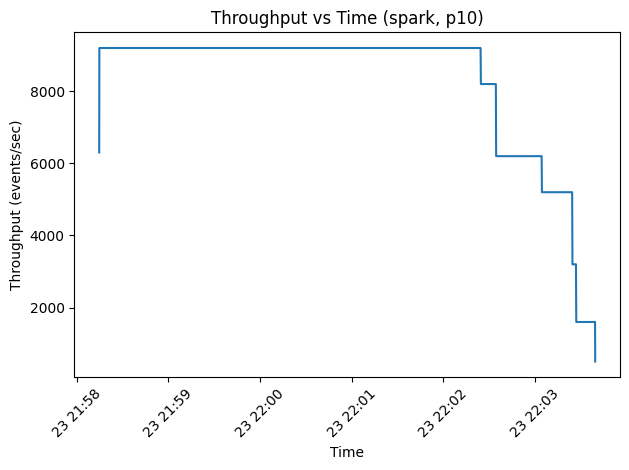

In [129]:
print("[PLOT] Throughput (time)...")
import matplotlib.pyplot as plt

for node, core_map in throughput_timeseries.items():
    for cores, tp in core_map.items():

        plt.figure()

        plt.plot(tp.index, tp.values)

        plt.title(f"Throughput vs Time ({node}, {cores})")
        plt.xlabel("Time")
        plt.ylabel("Throughput (events/sec)")
        plt.xticks(rotation=45)

        plt.tight_layout()
        plt.show()

In [96]:
node_data

{'spark':                                   auction   bidder    price  \
 processed_time                                                
 2026-04-23 23:55:14.039000+00:00  2700142  2700142  6991.60   
 2026-04-23 23:55:14.040000+00:00  7700740  7700740  6374.16   
 2026-04-23 23:55:14.041000+00:00  7700610  7700610  5738.56   
 2026-04-23 23:55:14.042000+00:00  7700480  7700480  5102.96   
 2026-04-23 23:55:14.043000+00:00  7700350  7700350  4467.36   
 ...                                   ...      ...      ...   
 2026-04-24 07:25:14.034000+00:00  1449271  1449271  5911.08   
 2026-04-24 07:25:14.035000+00:00  1449141  1449141  5275.48   
 2026-04-24 07:25:14.036000+00:00  1449011  1449011  4639.88   
 2026-04-24 07:25:14.037000+00:00  5200571  5200571  2823.88   
 2026-04-24 07:25:14.038000+00:00  7699999  7699999  6655.64   
 
                                                   dateTime  \
 processed_time                                               
 2026-04-23 23:55:14.039000+00:

In [97]:
print("[PLOT] Throughput vs cores...")
plt.figure()

core_values = [int(c.replace("p", "")) for c in cores_list]

# ---- per-node curves ----
for node, core_map in throughput_summary.items():
    y = []
    x = []

    for c in cores_list:
        if c in core_map:
            x.append(int(c.replace("p", "")))
            y.append(core_map[c])

    if len(y) > 0:
        plt.plot(x, y, marker="o", label=node)

# ---- cluster aggregation ----
cluster_curve = []

for c in cores_list:
    total = 0
    count = 0

    for node, core_map in throughput_summary.items():
        if c in core_map:
            total += core_map[c]
            count += 1

    if count > 0:
        cluster_curve.append(total)
    else:
        cluster_curve.append(None)

# clean missing points
x_clean = []
y_clean = []

for x, y in zip(core_values, cluster_curve):
    if y is not None:
        x_clean.append(x)
        y_clean.append(y)

plt.plot(x_clean, y_clean, marker="o", linewidth=3, color="black", label="cluster (n0+n1)")

plt.title(f"Throughput vs Cores ({query})")
plt.xlabel("Number of Cores")
plt.ylabel("Events/sec")
plt.grid(True, linestyle="--", alpha=0.5)
handles, labels = plt.gca().get_legend_handles_labels()
if labels:
    plt.legend()
else:
    print("[WARN] No data plotted → skipping legend")
plt.tight_layout()

plt.savefig(output_dir / f"throughput_vs_cores_{query}.png")
plt.close()

[PLOT] Throughput vs cores...
